In [ ]:
!pip install -U "protobuf>=6.31.1,<7"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.


In [1]:
!pip install -U "protobuf>=6.31.1,<7"
!pip install -U tensorflow-datasets importlib_resources

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 18.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.


In [2]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
import glob
import re

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_ROOT = "/content/drive/MyDrive/DL_Lab"

CHECKPOINT_ROOT = os.path.join(
    DRIVE_ROOT,
    "checkpoints"
)

CV_CHECKPOINT_ROOT = os.path.join(
    DRIVE_ROOT,
    "cv_checkpoints"
)

os.makedirs(CHECKPOINT_ROOT, exist_ok=True)
os.makedirs(CV_CHECKPOINT_ROOT, exist_ok=True)

print("Checkpoint folder:", CHECKPOINT_ROOT)
print("CV checkpoint folder:", CV_CHECKPOINT_ROOT)

CV_CHECKPOINT_DIR = CV_CHECKPOINT_ROOT

Mounted at /content/drive
Checkpoint folder: /content/drive/MyDrive/DL_Lab/checkpoints
CV checkpoint folder: /content/drive/MyDrive/DL_Lab/cv_checkpoints


In [ ]:

def get_latest_checkpoint(checkpoint_dir):

    checkpoints = glob.glob(
        os.path.join(
            checkpoint_dir,
            "epoch_*.keras"
        )
    )

    if not checkpoints:
        return None, 0

    def extract_epoch(path):

        filename = os.path.basename(path)

        match = re.search(
            r"epoch_(\d+)",
            filename
        )

        if match:
            return int(match.group(1))

        return 0

    checkpoints = sorted(
        checkpoints,
        key=extract_epoch
    )

    latest_checkpoint = checkpoints[-1]

    completed_epoch = extract_epoch(
        latest_checkpoint
    )

    return latest_checkpoint, completed_epoch

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 37

AUTOTUNE = tf.data.AUTOTUNE

In [6]:
import tensorflow_datasets as tfds

(ds_train_full, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

print(ds_info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='/root/tensorflow_datasets/oxford_iiit_pet/4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
       

In [7]:
print("Training examples:", ds_info.splits["train"].num_examples)
print("Test examples:", ds_info.splits["test"].num_examples)

Training examples: 3680
Test examples: 3669


In [8]:
print("Number of classes:", ds_info.features["label"].num_classes)
print("Class names:", ds_info.features["label"].names)

Number of classes: 37
Class names: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair', 'chihuahua', 'Egyptian_Mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'Maine_Coon', 'miniature_pinscher', 'newfoundland', 'Persian', 'pomeranian', 'pug', 'Ragdoll', 'Russian_Blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'Siamese', 'Sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']


In [9]:
for image, label in ds_train_full.take(1):
    print("Image shape:", image.shape)
    print("Label:", label.numpy())

Image shape: (500, 500, 3)
Label: 33


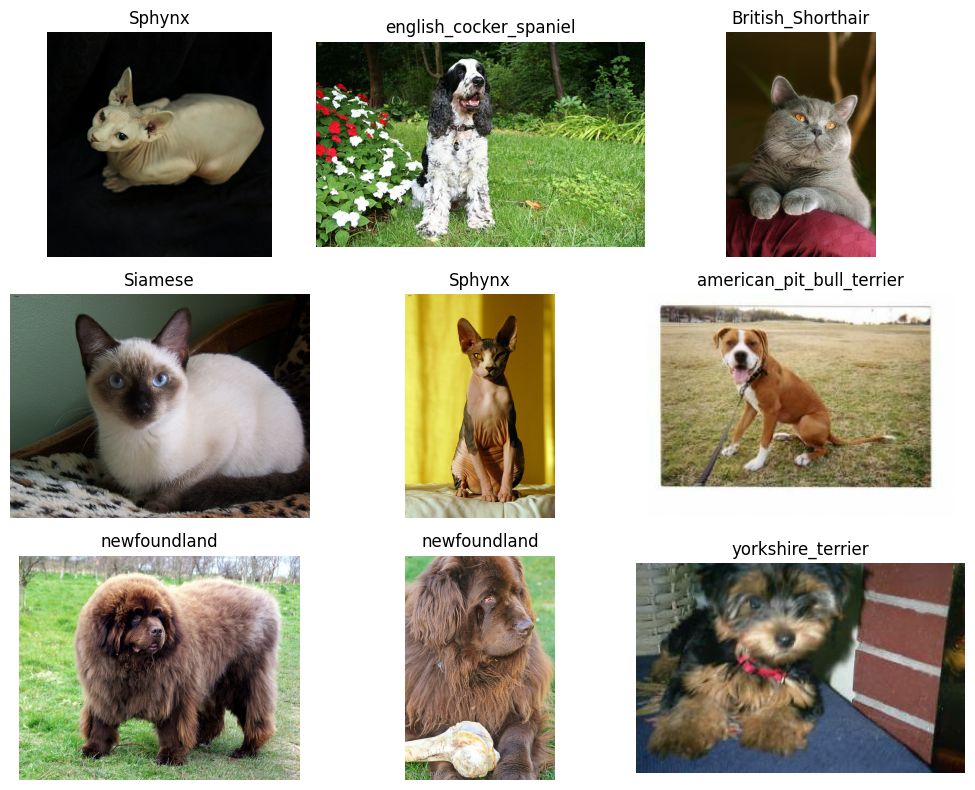

In [10]:
plt.figure(figsize=(10, 8))

for i, (image, label) in enumerate(ds_train_full.take(9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(ds_info.features["label"].names[label.numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
total_train = ds_info.splits["train"].num_examples

train_count = int(0.8 * total_train)

ds_train = ds_train_full.take(train_count)
ds_val = ds_train_full.skip(train_count)

print("Training:", train_count)
print("Validation:", total_train - train_count)
print("Test:", ds_info.splits["test"].num_examples)

Training: 2944
Validation: 736
Test: 3669


In [12]:
IMG_SIZE = (224, 224)

def preprocess_image(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

In [13]:
#testing the preprocessing
for image, label in ds_train.map(preprocess_image).take(1):
    print("Processed image shape:", image.shape)
    print("Processed image dtype:", image.dtype)
    print("Label:", label.numpy())

Processed image shape: (224, 224, 3)
Processed image dtype: <dtype: 'float32'>
Label: 33


In [14]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    ds_train
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    ds_val
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    ds_test
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [15]:
for images, labels in train_ds.take(3):
    print("Batch image shape:", images.shape)
    print("Batch image dtype:", images.dtype)
    print("Batch label shape:", labels.shape)

Batch image shape: (32, 224, 224, 3)
Batch image dtype: <dtype: 'float32'>
Batch label shape: (32,)
Batch image shape: (32, 224, 224, 3)
Batch image dtype: <dtype: 'float32'>
Batch label shape: (32,)
Batch image shape: (32, 224, 224, 3)
Batch image dtype: <dtype: 'float32'>
Batch label shape: (32,)


In [16]:
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

In [16]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("MobileNetV2 loaded")
print("Number of layers:", len(base_model.layers))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded
Number of layers: 154


In [17]:
base_model.trainable = False
print("Trainable:", base_model.trainable)

Trainable: False


In [18]:
inputs = keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(37, activation="softmax")(x)

baseline_model = keras.Model(inputs, outputs)

baseline_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
trainable_params = np.sum([
    np.prod(v.shape)
    for v in baseline_model.trainable_weights
])

non_trainable_params = np.sum([
    np.prod(v.shape)
    for v in baseline_model.non_trainable_weights
])

print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

Trainable parameters: 47397
Non-trainable parameters: 2257984


In [21]:
EPOCHS = 5

start_time = time.time()

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

baseline_training_time = time.time() - start_time

print("Training time:", baseline_training_time, "seconds")

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 43s 230ms/step - accuracy: 0.6906 - loss: 1.2878 - val_accuracy: 0.8696 - val_loss: 0.5145
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 156ms/step - accuracy: 0.9266 - loss: 0.3117 - val_accuracy: 0.8899 - val_loss: 0.3750
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 159ms/step - accuracy: 0.9609 - loss: 0.1974 - val_accuracy: 0.8954 - val_loss: 0.3280
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 155ms/step - accuracy: 0.9738 - loss: 0.1369 - val_accuracy: 0.9076 - val_loss: 0.2952
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 157ms/step - accuracy: 0.9861 - loss: 0.1010 - val_accuracy: 0.9049 - val_loss: 0.2834
Training time: 121.141685962677 seconds


In [22]:
print("Final training accuracy:",
      baseline_history.history["accuracy"][-1])

print("Final validation accuracy:",
      baseline_history.history["val_accuracy"][-1])

print("Final training loss:",
      baseline_history.history["loss"][-1])

print("Final validation loss:",
      baseline_history.history["val_loss"][-1])

Final training accuracy: 0.98607337474823
Final validation accuracy: 0.904891312122345
Final training loss: 0.1010076254606247
Final validation loss: 0.2833511531352997


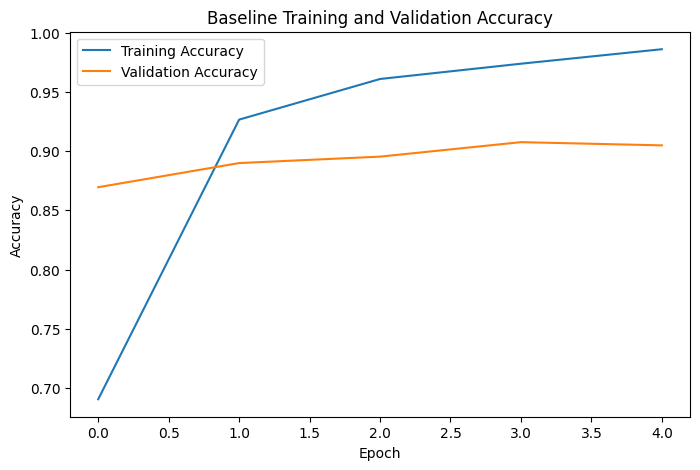

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Training and Validation Accuracy")
plt.legend()
plt.show()

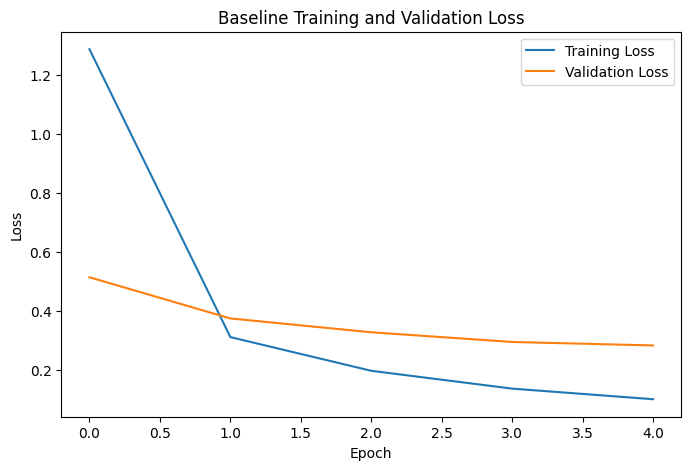

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Training and Validation Loss")
plt.legend()
plt.show()

In [25]:
##weight initialization

In [26]:
def build_initialization_model(initializer):

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        kernel_initializer=initializer
    )(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [27]:
initializers = {
    "Zero": keras.initializers.Zeros(),
    "Random": keras.initializers.RandomNormal(mean=0.0, stddev=0.05),
    "Xavier": keras.initializers.GlorotUniform(),
    "He": keras.initializers.HeNormal()
}

In [28]:
initialization_histories = {}

for name, initializer in initializers.items():
    print("\nTraining:", name)
    model = build_initialization_model(initializer)
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        verbose=1
    )

    initialization_histories[name] = history


Training: Zero
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 303ms/step - accuracy: 0.7772 - loss: 1.1455 - val_accuracy: 0.8995 - val_loss: 0.4527
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 159ms/step - accuracy: 0.9402 - loss: 0.2883 - val_accuracy: 0.9035 - val_loss: 0.3452
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 179ms/step - accuracy: 0.9657 - loss: 0.1845 - val_accuracy: 0.9049 - val_loss: 0.3109
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 154ms/step - accuracy: 0.9817 - loss: 0.1282 - val_accuracy: 0.9117 - val_loss: 0.2742
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 165ms/step - accuracy: 0.9908 - loss: 0.0944 - val_accuracy: 0.9117 - val_loss: 0.2621

Training: Random
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 213ms/step - accuracy: 0.6647 - loss: 1.3525 - val_accuracy: 0.8560 - val_loss: 0.5253
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step - accuracy: 0.9147 - loss: 0.3260 - val_accuracy: 0.8899 - val_loss: 0.3774
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 160ms/step - accuracy: 0.9490

##Training loss

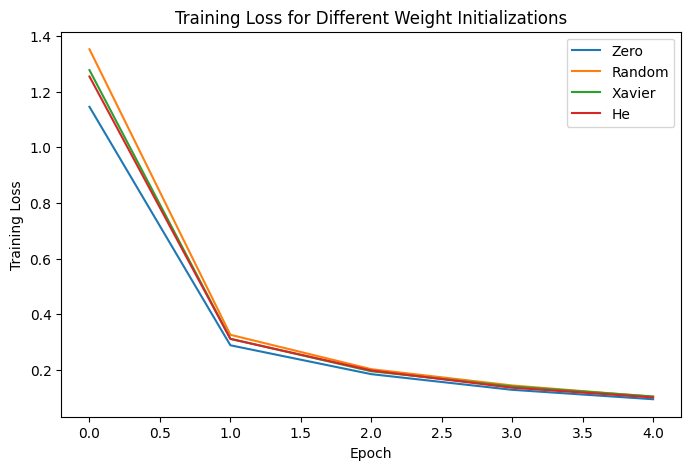

In [29]:
plt.figure(figsize=(8, 5))

for name, history in initialization_histories.items():
    plt.plot(
        history.history["loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Weight Initializations")
plt.legend()
plt.show()

##validation accuracy

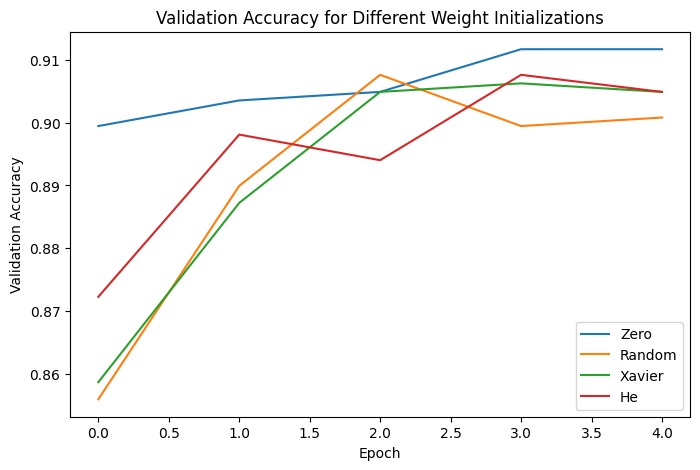

In [30]:
plt.figure(figsize=(8, 5))

for name, history in initialization_histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different Weight Initializations")
plt.legend()
plt.show()

##Regularization

In [31]:
def build_regularization_model(reg_type):

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    if reg_type == "l2":

        x = layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        )(x)

    else:

        x = layers.Dense(
            128,
            activation="relu"
        )(x)

    if reg_type == "dropout":
        x = layers.Dropout(0.5)(x)

    if reg_type == "batchnorm":
        x = layers.BatchNormalization()(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [32]:
regularization_types = [
    "none",
    "l2",
    "dropout",
    "batchnorm"
]

regularization_histories = {}

for reg_type in regularization_types:

    print("\nTraining:", reg_type)

    model = build_regularization_model(reg_type)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        verbose=1
    )

    regularization_histories[reg_type] = history


Training: none
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 215ms/step - accuracy: 0.7157 - loss: 1.1078 - val_accuracy: 0.8628 - val_loss: 0.4011
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 156ms/step - accuracy: 0.9324 - loss: 0.2239 - val_accuracy: 0.8764 - val_loss: 0.3787
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 158ms/step - accuracy: 0.9620 - loss: 0.1315 - val_accuracy: 0.8899 - val_loss: 0.3140
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 159ms/step - accuracy: 0.9861 - loss: 0.0707 - val_accuracy: 0.8995 - val_loss: 0.2784
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step - accuracy: 0.9942 - loss: 0.0398 - val_accuracy: 0.9008 - val_loss: 0.2768

Training: l2
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 200ms/step - accuracy: 0.7269 - loss: 1.3016 - val_accuracy: 0.8845 - val_loss: 0.6255
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 156ms/step - accuracy: 0.9317 - loss: 0.4549 - val_accuracy: 0.8872 - val_loss: 0.5842
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 158ms/step - accuracy: 0.9671 - l

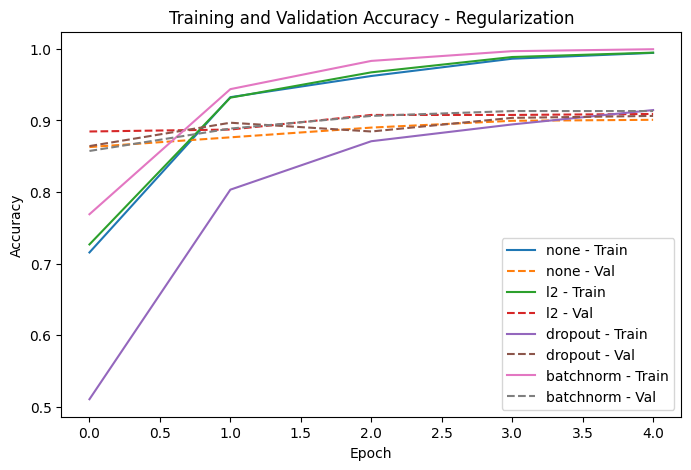

In [33]:
plt.figure(figsize=(8, 5))

for name, history in regularization_histories.items():

    plt.plot(
        history.history["accuracy"],
        label=f"{name} - Train"
    )

    plt.plot(
        history.history["val_accuracy"],
        linestyle="--",
        label=f"{name} - Val"
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy - Regularization")
plt.legend()
plt.show()

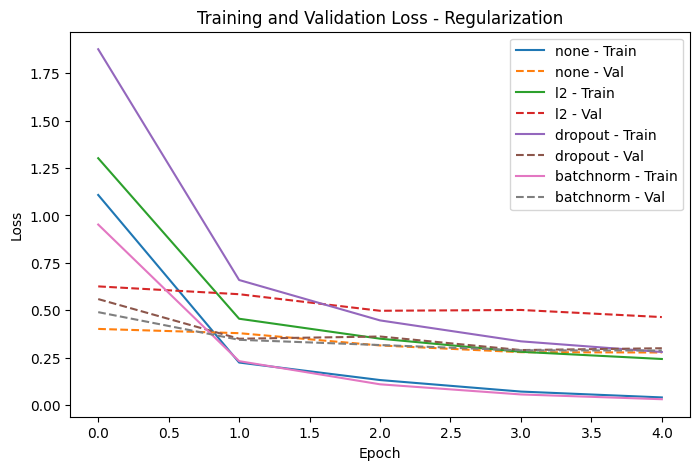

In [34]:
plt.figure(figsize=(8, 5))

for name, history in regularization_histories.items():

    plt.plot(
        history.history["loss"],
        label=f"{name} - Train"
    )

    plt.plot(
        history.history["val_loss"],
        linestyle="--",
        label=f"{name} - Val"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss - Regularization")
plt.legend()
plt.show()

##Batch Norm

In [35]:
def build_bn_model(use_bn):

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)

    if use_bn:
        x = layers.BatchNormalization()(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [36]:
bn_histories = {}

for name, use_bn in {
    "Without BN": False,
    "With BN": True
}.items():

    print("\nTraining:", name)

    model = build_bn_model(use_bn)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5
    )

    bn_histories[name] = history


Training: Without BN
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 198ms/step - accuracy: 0.7422 - loss: 1.0193 - val_accuracy: 0.8832 - val_loss: 0.3715
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step - accuracy: 0.9344 - loss: 0.2172 - val_accuracy: 0.8859 - val_loss: 0.3163
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 152ms/step - accuracy: 0.9698 - loss: 0.1185 - val_accuracy: 0.9035 - val_loss: 0.3019
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 156ms/step - accuracy: 0.9874 - loss: 0.0659 - val_accuracy: 0.8967 - val_loss: 0.3146
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 154ms/step - accuracy: 0.9976 - loss: 0.0380 - val_accuracy: 0.9062 - val_loss: 0.3026

Training: With BN
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 204ms/step - accuracy: 0.7615 - loss: 0.9550 - val_accuracy: 0.8845 - val_loss: 0.4356
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 150ms/step - accuracy: 0.9453 - loss: 0.2234 - val_accuracy: 0.8954 - val_loss: 0.3394
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 154ms/step - accuracy:

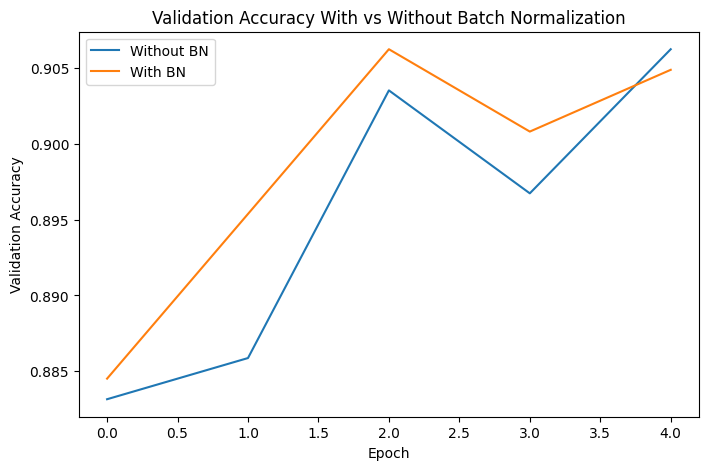

In [37]:
plt.figure(figsize=(8, 5))

for name, history in bn_histories.items():

    plt.plot(
        history.history["val_accuracy"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy With vs Without Batch Normalization")
plt.legend()
plt.show()

##Optimizers

In [38]:
def build_optimizer_model():

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    return keras.Model(inputs, outputs)

In [39]:
optimizers = {
    "SGD": keras.optimizers.SGD(learning_rate=0.001),

    "Momentum": keras.optimizers.SGD(
        learning_rate=0.001,
        momentum=0.9
    ),

    "RMSProp": keras.optimizers.RMSprop(
        learning_rate=0.001
    ),

    "Adam": keras.optimizers.Adam(
        learning_rate=0.001
    )
}

In [40]:
optimizer_histories = {}

for name, optimizer in optimizers.items():

    print("\nTraining:", name)

    model = build_optimizer_model()

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5
    )

    optimizer_histories[name] = history


Training: SGD
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 227ms/step - accuracy: 0.0489 - loss: 3.8133 - val_accuracy: 0.0598 - val_loss: 3.6609
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 156ms/step - accuracy: 0.0968 - loss: 3.4834 - val_accuracy: 0.1073 - val_loss: 3.3768
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 164ms/step - accuracy: 0.1681 - loss: 3.2010 - val_accuracy: 0.1793 - val_loss: 3.1257
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - accuracy: 0.2524 - loss: 2.9480 - val_accuracy: 0.2582 - val_loss: 2.8968
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 154ms/step - accuracy: 0.3458 - loss: 2.7177 - val_accuracy: 0.3342 - val_loss: 2.6870

Training: Momentum
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 214ms/step - accuracy: 0.3060 - loss: 2.8475 - val_accuracy: 0.6209 - val_loss: 1.8657
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - accuracy: 0.7660 - loss: 1.3587 - val_accuracy: 0.8030 - val_loss: 1.0600
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step - accuracy: 0.851

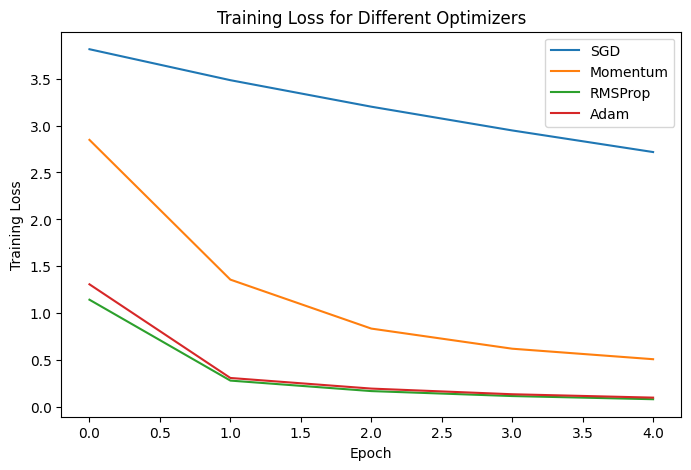

In [41]:
plt.figure(figsize=(8, 5))

for name, history in optimizer_histories.items():

    plt.plot(
        history.history["loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Optimizers")
plt.legend()
plt.show()

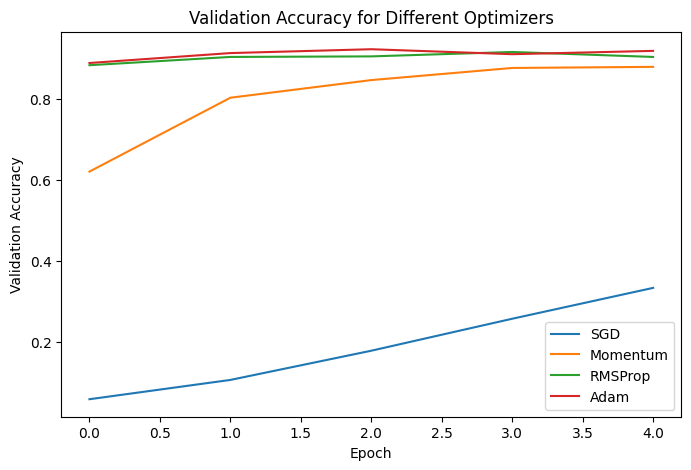

In [42]:
plt.figure(figsize=(8, 5))

for name, history in optimizer_histories.items():

    plt.plot(
        history.history["val_accuracy"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different Optimizers")
plt.legend()
plt.show()

In [43]:
optimizer_results = []

for name, history in optimizer_histories.items():

    optimizer_results.append({
        "Optimizer": name,
        "Final Loss": history.history["loss"][-1],
        "Best Val Accuracy": max(history.history["val_accuracy"]),
        "Epoch to Best": np.argmax(
            history.history["val_accuracy"]
        ) + 1
    })

optimizer_results_df = pd.DataFrame(optimizer_results)

optimizer_results_df

,Optimizer,Final Loss,Best Val Accuracy,Epoch to Best
0,SGD,2.717734,0.334239,5
1,Momentum,0.510656,0.879076,5
2,RMSProp,0.084338,0.915761,4
3,Adam,0.101329,0.922554,3


##Hyperparameter tuning

In [44]:
# ==========================================
# HYPERPARAMETER TUNING MODEL
# ==========================================

def build_hyperparameter_model(dropout_rate=0.0):

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze pretrained MobileNetV2
    base_model.trainable = False

    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    if dropout_rate > 0:
        x = layers.Dropout(
            dropout_rate
        )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = keras.Model(
        inputs,
        outputs
    )

    return model

In [45]:
# ==========================================
# LEARNING RATE EXPERIMENT
# ==========================================

learning_rates = [
    0.001,
    0.0001
]

learning_rate_histories = {}
learning_rate_models = {}

for lr in learning_rates:

    print("\n====================================")
    print("Learning Rate:", lr)
    print("====================================")

    model = build_hyperparameter_model(
        dropout_rate=0.0
    )

    optimizer = keras.optimizers.Adam(
        learning_rate=lr
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        verbose=1
    )

    training_time = time.time() - start_time

    learning_rate_histories[lr] = history
    learning_rate_models[lr] = model

    print(
        f"Training time: {training_time:.2f} seconds"
    )


Learning Rate: 0.001
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 217ms/step - accuracy: 0.6824 - loss: 1.3316 - val_accuracy: 0.8777 - val_loss: 0.5040
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 156ms/step - accuracy: 0.9266 - loss: 0.3174 - val_accuracy: 0.9008 - val_loss: 0.3736
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 157ms/step - accuracy: 0.9565 - loss: 0.2025 - val_accuracy: 0.9117 - val_loss: 0.3233
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 155ms/step - accuracy: 0.9738 - loss: 0.1403 - val_accuracy: 0.9171 - val_loss: 0.2896
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - accuracy: 0.9861 - loss: 0.1048 - val_accuracy: 0.9226 - val_loss: 0.2775
Training time: 101.52 seconds

Learning Rate: 0.0001
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 213ms/step - accuracy: 0.1399 - loss: 3.3017 - val_accuracy: 0.3274 - val_loss: 2.6899
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step - accuracy: 0.5071 - loss: 2.2819 - val_accuracy: 0.6427 - val_loss: 1.9064
Epoch 3/5
92/92 ━━━━━━━━━━━━━

In [46]:
# ==========================================
# LEARNING RATE RESULTS
# ==========================================

learning_rate_results = []

for lr, history in learning_rate_histories.items():

    learning_rate_results.append({

        "Learning Rate": lr,

        "Best Validation Accuracy":
            max(history.history["val_accuracy"]),

        "Best Epoch":
            np.argmax(
                history.history["val_accuracy"]
            ) + 1,

        "Final Training Loss":
            history.history["loss"][-1],

        "Final Validation Loss":
            history.history["val_loss"][-1]
    })

learning_rate_df = pd.DataFrame(
    learning_rate_results
)

learning_rate_df

,Learning Rate,Best Validation Accuracy,Best Epoch,Final Training Loss,Final Validation Loss
0,0.0010,0.922554,5,0.104824,0.277499
1,0.0001,0.854620,5,0.913356,0.888488


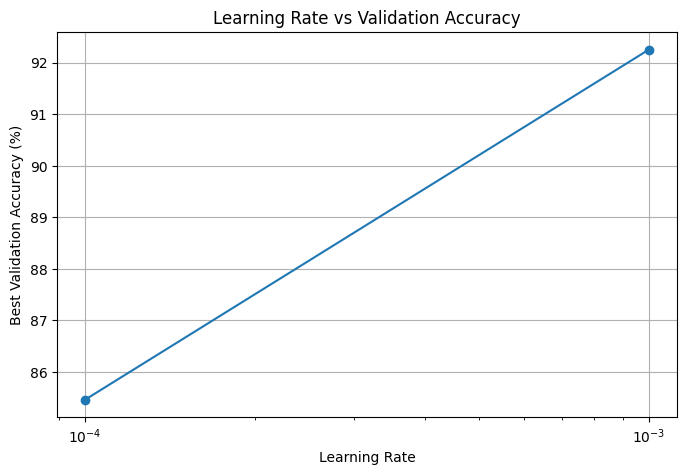

In [47]:
# ==========================================
# PLOT 8
# ==========================================

lr_values = []
lr_accuracies = []

for lr, history in learning_rate_histories.items():

    lr_values.append(lr)

    lr_accuracies.append(
        max(
            history.history["val_accuracy"]
        ) * 100
    )

plt.figure(figsize=(8, 5))

plt.plot(
    lr_values,
    lr_accuracies,
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("Best Validation Accuracy (%)")

plt.title(
    "Learning Rate vs Validation Accuracy"
)

plt.xscale("log")
plt.grid(True)

plt.show()

In [48]:
# ==========================================
# CREATE DATASETS FOR DIFFERENT BATCH SIZES
# ==========================================

def make_datasets(batch_size):

    train_dataset = (
        ds_train
        .map(
            preprocess_image,
            num_parallel_calls=AUTOTUNE
        )
        .shuffle(1000)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )

    val_dataset = (
        ds_val
        .map(
            preprocess_image,
            num_parallel_calls=AUTOTUNE
        )
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )

    return train_dataset, val_dataset

In [49]:
# ==========================================
# BATCH SIZE EXPERIMENT
# ==========================================

batch_sizes = [
    16,
    32,
    64
]

batch_size_histories = {}
batch_size_models = {}

for batch_size in batch_sizes:

    print("\n====================================")
    print("Batch Size:", batch_size)
    print("====================================")

    train_data, val_data = make_datasets(
        batch_size
    )

    model = build_hyperparameter_model(
        dropout_rate=0.0
    )

    optimizer = keras.optimizers.Adam(
        learning_rate=0.001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=5,
        verbose=1
    )

    training_time = time.time() - start_time

    batch_size_histories[
        batch_size
    ] = history

    batch_size_models[
        batch_size
    ] = model

    print(
        f"Training time: {training_time:.2f} seconds"
    )


Batch Size: 16
Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 38s 104ms/step - accuracy: 0.7517 - loss: 1.0255 - val_accuracy: 0.8927 - val_loss: 0.4153
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 82ms/step - accuracy: 0.9348 - loss: 0.2457 - val_accuracy: 0.8967 - val_loss: 0.3222
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - accuracy: 0.9718 - loss: 0.1418 - val_accuracy: 0.9090 - val_loss: 0.2934
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 22s 82ms/step - accuracy: 0.9864 - loss: 0.0920 - val_accuracy: 0.9049 - val_loss: 0.2668
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.9946 - loss: 0.0652 - val_accuracy: 0.9117 - val_loss: 0.2619
Training time: 112.17 seconds

Batch Size: 32
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 208ms/step - accuracy: 0.7069 - loss: 1.2441 - val_accuracy: 0.8818 - val_loss: 0.4865
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step - accuracy: 0.9266 - loss: 0.3118 - val_accuracy: 0.8832 - val_loss: 0.3665
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━

In [50]:
# ==========================================
# BATCH SIZE RESULTS
# ==========================================

batch_size_results = []

for batch_size, history in batch_size_histories.items():

    batch_size_results.append({

        "Batch Size": batch_size,

        "Best Validation Accuracy":
            max(
                history.history["val_accuracy"]
            ),

        "Best Epoch":
            np.argmax(
                history.history["val_accuracy"]
            ) + 1,

        "Final Training Loss":
            history.history["loss"][-1],

        "Final Validation Loss":
            history.history["val_loss"][-1]
    })

batch_size_df = pd.DataFrame(
    batch_size_results
)

batch_size_df

,Batch Size,Best Validation Accuracy,Best Epoch,Final Training Loss,Final Validation Loss
0,16,0.911685,5,0.065186,0.261896
1,32,0.908967,5,0.100870,0.283337
2,64,0.906250,5,0.158156,0.321740


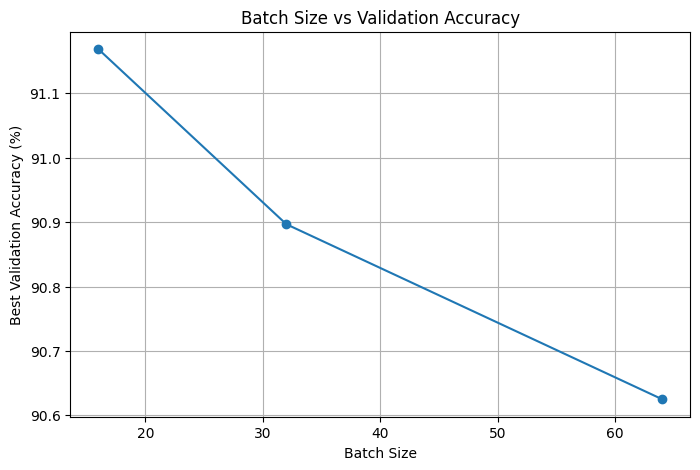

In [51]:
# ==========================================
# PLOT 9
# ==========================================

batch_values = []
batch_accuracies = []

for batch_size, history in batch_size_histories.items():

    batch_values.append(batch_size)

    batch_accuracies.append(
        max(
            history.history["val_accuracy"]
        ) * 100
    )

plt.figure(figsize=(8, 5))

plt.plot(
    batch_values,
    batch_accuracies,
    marker="o"
)

plt.xlabel("Batch Size")
plt.ylabel("Best Validation Accuracy (%)")

plt.title(
    "Batch Size vs Validation Accuracy"
)

plt.grid(True)

plt.show()

In [52]:
# ==========================================
# DROPOUT EXPERIMENT
# ==========================================

dropout_rates = [
    0.0,
    0.25,
    0.5
]

dropout_histories = {}
dropout_models = {}

for dropout_rate in dropout_rates:

    print("\n====================================")
    print("Dropout Rate:", dropout_rate)
    print("====================================")

    model = build_hyperparameter_model(
        dropout_rate=dropout_rate
    )

    optimizer = keras.optimizers.Adam(
        learning_rate=0.001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        verbose=1
    )

    training_time = time.time() - start_time

    dropout_histories[
        dropout_rate
    ] = history

    dropout_models[
        dropout_rate
    ] = model

    print(
        f"Training time: {training_time:.2f} seconds"
    )


Dropout Rate: 0.0
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 201ms/step - accuracy: 0.7116 - loss: 1.2605 - val_accuracy: 0.8845 - val_loss: 0.4859
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 158ms/step - accuracy: 0.9304 - loss: 0.3114 - val_accuracy: 0.9008 - val_loss: 0.3734
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 155ms/step - accuracy: 0.9620 - loss: 0.1935 - val_accuracy: 0.9130 - val_loss: 0.3201
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 0.9759 - loss: 0.1361 - val_accuracy: 0.9062 - val_loss: 0.3037
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 163ms/step - accuracy: 0.9891 - loss: 0.1002 - val_accuracy: 0.9185 - val_loss: 0.2750
Training time: 100.33 seconds

Dropout Rate: 0.25
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 201ms/step - accuracy: 0.6332 - loss: 1.4462 - val_accuracy: 0.8655 - val_loss: 0.5365
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 155ms/step - accuracy: 0.8995 - loss: 0.3952 - val_accuracy: 0.8913 - val_loss: 0.3764
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━

In [53]:
# ==========================================
# DROPOUT RESULTS
# ==========================================

dropout_results = []

for dropout_rate, history in dropout_histories.items():

    dropout_results.append({

        "Dropout Rate": dropout_rate,

        "Best Validation Accuracy":
            max(
                history.history["val_accuracy"]
            ),

        "Best Epoch":
            np.argmax(
                history.history["val_accuracy"]
            ) + 1,

        "Final Training Loss":
            history.history["loss"][-1],

        "Final Validation Loss":
            history.history["val_loss"][-1]
    })

dropout_df = pd.DataFrame(
    dropout_results
)

dropout_df

,Dropout Rate,Best Validation Accuracy,Best Epoch,Final Training Loss,Final Validation Loss
0,0.00,0.918478,5,0.100207,0.274973
1,0.25,0.915761,5,0.146716,0.277856
2,0.50,0.919837,3,0.224569,0.291384


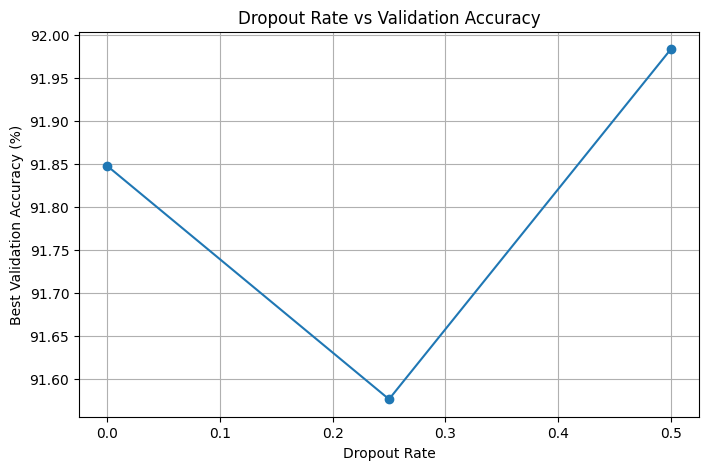

In [54]:
# ==========================================
# PLOT 10
# ==========================================

dropout_values = []
dropout_accuracies = []

for dropout_rate, history in dropout_histories.items():

    dropout_values.append(
        dropout_rate
    )

    dropout_accuracies.append(
        max(
            history.history["val_accuracy"]
        ) * 100
    )

plt.figure(figsize=(8, 5))

plt.plot(
    dropout_values,
    dropout_accuracies,
    marker="o"
)

plt.xlabel("Dropout Rate")
plt.ylabel("Best Validation Accuracy (%)")

plt.title(
    "Dropout Rate vs Validation Accuracy"
)

plt.grid(True)

plt.show()

In [55]:
# ==========================================
# HYPERPARAMETER SUMMARY
# ==========================================
hyperparameter_results = []

for _, row in learning_rate_df.iterrows():

    hyperparameter_results.append({

        "Experiment": "Learning Rate",

        "Value": row["Learning Rate"],

        "Best Validation Accuracy":
            row["Best Validation Accuracy"]
    })


for _, row in batch_size_df.iterrows():

    hyperparameter_results.append({

        "Experiment": "Batch Size",

        "Value": row["Batch Size"],

        "Best Validation Accuracy":
            row["Best Validation Accuracy"]
    })


for _, row in dropout_df.iterrows():

    hyperparameter_results.append({

        "Experiment": "Dropout Rate",

        "Value": row["Dropout Rate"],

        "Best Validation Accuracy":
            row["Best Validation Accuracy"]
    })


hyperparameter_summary_df = pd.DataFrame(
    hyperparameter_results
)

hyperparameter_summary_df

,Experiment,Value,Best Validation Accuracy
0,Learning Rate,0.0010,0.922554
1,Learning Rate,0.0001,0.854620
2,Batch Size,16.0000,0.911685
3,Batch Size,32.0000,0.908967
4,Batch Size,64.0000,0.906250
5,Dropout Rate,0.0000,0.918478
6,Dropout Rate,0.2500,0.915761
7,Dropout Rate,0.5000,0.919837


In [19]:
# ==========================================
# BEST HYPERPARAMETER MODEL
# ==========================================

BEST_DROPOUT = 0.5
BEST_BATCH_SIZE = 16
BEST_LR = 0.001

def build_transfer_model(dropout_rate=0.5):

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Feature extraction stage:
    # freeze entire pretrained network
    base_model.trainable = False

    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(
        dropout_rate
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = keras.Model(
        inputs,
        outputs
    )

    return model, base_model

##Fine Tuning

In [20]:
# ==========================================
# STAGE A: FEATURE EXTRACTION
# ==========================================

feature_model, feature_base = build_transfer_model(
    dropout_rate=BEST_DROPOUT
)

feature_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=BEST_LR
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

feature_history = feature_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

feature_training_time = (
    time.time() - start_time
)

print(
    "Feature extraction training time:",
    feature_training_time,
    "seconds"
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 209ms/step - accuracy: 0.5194 - loss: 1.8252 - val_accuracy: 0.8628 - val_loss: 0.6158
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 189ms/step - accuracy: 0.8502 - loss: 0.5270 - val_accuracy: 0.8899 - val_loss: 0.4131
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 163ms/step - accuracy: 0.8923 - loss: 0.3720 - val_accuracy: 0.8913 - val_loss: 0.3471
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 163ms/step - accuracy: 0.9205 - loss: 0.2718 - val_accuracy: 0.9144 - val_loss: 0.3082
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 164ms/step - accuracy: 0.9423 - loss: 0.2184 - val_accuracy: 0.9035 - val_loss: 0.2952
Feature extraction training time: 114.40817141532898 seconds


In [21]:
# ==========================================
# MOBILE NET V2 LAYER STATUS
# ==========================================

print(
    "Total MobileNetV2 layers:",
    len(feature_base.layers)
)

print(
    "Trainable MobileNetV2 layers:",
    sum(
        layer.trainable
        for layer in feature_base.layers
    )
)

Total MobileNetV2 layers: 154
Trainable MobileNetV2 layers: 0


In [22]:
# ==========================================
# STAGE B: PARTIAL UNFREEZING
# ==========================================

UNFREEZE_LAYERS = 30

feature_base.trainable = True

# Freeze all earlier layers
for layer in feature_base.layers[:-UNFREEZE_LAYERS]:

    layer.trainable = False

print(
    "Total MobileNetV2 layers:",
    len(feature_base.layers)
)

print(
    "Trainable MobileNetV2 layers:",
    sum(
        layer.trainable
        for layer in feature_base.layers
    )
)

Total MobileNetV2 layers: 154
Trainable MobileNetV2 layers: 30


In [23]:
# ==========================================
# RECOMPILE FOR FINE-TUNING
# ==========================================

FINE_TUNE_LR = 1e-5

feature_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
# ==========================================
# FINE-TUNING
# ==========================================

start_time = time.time()

fine_tune_history = feature_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

fine_tuning_time = (
    time.time() - start_time
)

print(
    "Fine-tuning time:",
    fine_tuning_time,
    "seconds"
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 219ms/step - accuracy: 0.8804 - loss: 0.3876 - val_accuracy: 0.9022 - val_loss: 0.2840
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - accuracy: 0.8933 - loss: 0.3421 - val_accuracy: 0.9062 - val_loss: 0.2785
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - accuracy: 0.9120 - loss: 0.2805 - val_accuracy: 0.9049 - val_loss: 0.2764
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 188ms/step - accuracy: 0.9164 - loss: 0.2644 - val_accuracy: 0.9090 - val_loss: 0.2747
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.9307 - loss: 0.2290 - val_accuracy: 0.9076 - val_loss: 0.2701
Fine-tuning time: 115.15004181861877 seconds


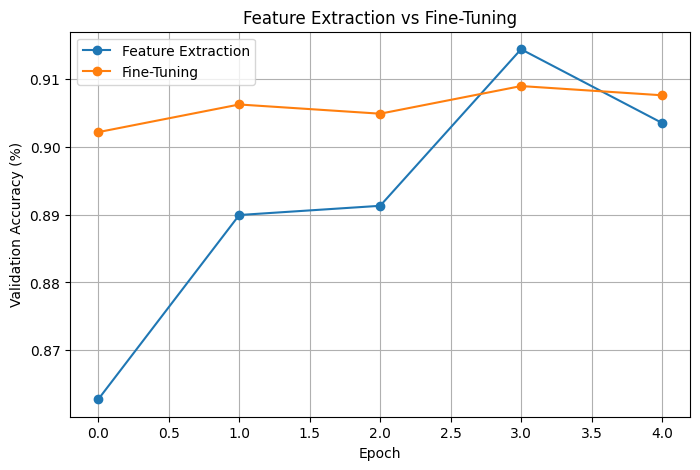

In [25]:
# ==========================================
# PLOT 11
# FEATURE EXTRACTION VS FINE-TUNING
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    feature_history.history["val_accuracy"],
    marker="o",
    label="Feature Extraction"
)

plt.plot(
    fine_tune_history.history["val_accuracy"],
    marker="o",
    label="Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Feature Extraction vs Fine-Tuning"
)

plt.legend()
plt.grid(True)

plt.show()

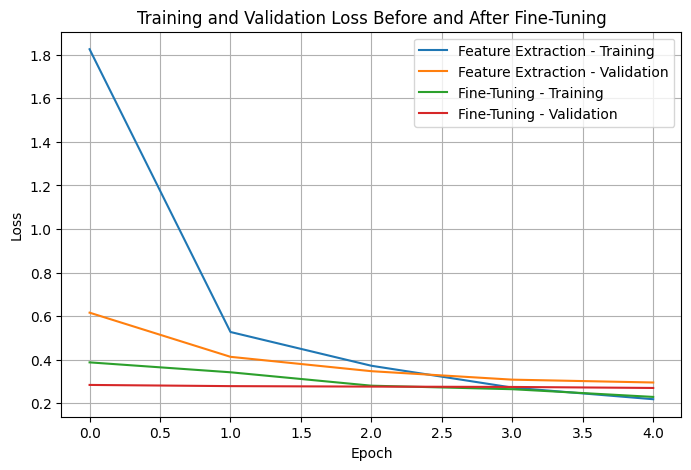

In [26]:
# ==========================================
# PLOT 12
# TRAINING AND VALIDATION LOSS
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    feature_history.history["loss"],
    label="Feature Extraction - Training"
)

plt.plot(
    feature_history.history["val_loss"],
    label="Feature Extraction - Validation"
)

plt.plot(
    fine_tune_history.history["loss"],
    label="Fine-Tuning - Training"
)

plt.plot(
    fine_tune_history.history["val_loss"],
    label="Fine-Tuning - Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss Before and After Fine-Tuning"
)

plt.legend()
plt.grid(True)

plt.show()

##k fold-cv

In [17]:
# ==========================================
# PREPARE DATA FOR 5-FOLD CROSS-VALIDATION
# ==========================================

cv_images = []
cv_labels = []

for image, label in ds_train:

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = preprocess_input(image)

    cv_images.append(
        image.numpy()
    )

    cv_labels.append(
        label.numpy()
    )

cv_images = np.array(cv_images)
cv_labels = np.array(cv_labels)

print("CV images shape:", cv_images.shape)
print("CV labels shape:", cv_labels.shape)

CV images shape: (2944, 224, 224, 3)
CV labels shape: (2944,)


In [18]:
# ==========================================
# STRATIFIED 5-FOLD CROSS-VALIDATION
# ==========================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print("Number of folds:", skf.n_splits)

Number of folds: 5


In [19]:
# ==========================================
# CANDIDATE CONFIGURATIONS
# ==========================================

cv_configurations = {

    "C1": {
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "batch_size": 32,
        "dropout": 0.0
    },

    "C2": {
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "batch_size": 16,
        "dropout": 0.0
    },

    "C3": {
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "batch_size": 32,
        "dropout": 0.5
    },

    "C4": {
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "batch_size": 16,
        "dropout": 0.5
    }
}

cv_configurations

{'C1': {'optimizer': 'Adam',
  'learning_rate': 0.001,
  'batch_size': 32,
  'dropout': 0.0},
 'C2': {'optimizer': 'Adam',
  'learning_rate': 0.001,
  'batch_size': 16,
  'dropout': 0.0},
 'C3': {'optimizer': 'Adam',
  'learning_rate': 0.001,
  'batch_size': 32,
  'dropout': 0.5},
 'C4': {'optimizer': 'Adam',
  'learning_rate': 0.001,
  'batch_size': 16,
  'dropout': 0.5}}

In [20]:
# ==========================================
# MODEL BUILDER FOR CV
# ==========================================

def build_cv_model(dropout_rate):

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    if dropout_rate > 0:
        x = layers.Dropout(
            dropout_rate
        )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = keras.Model(
        inputs,
        outputs
    )

    return model

In [21]:
def run_5fold_cv(config_name, config, epochs=5):
    config_dir = os.path.join(CV_CHECKPOINT_DIR, config_name)
    os.makedirs(config_dir, exist_ok=True)

    results_file = os.path.join(config_dir, "fold_results.csv")
    fold_results = pd.read_csv(results_file).to_dict("records") if os.path.exists(results_file) else []
    completed_folds = {int(r["Fold"]) for r in fold_results}

    for fold, (train_idx, val_idx) in enumerate(skf.split(cv_images, cv_labels), 1):
        if fold in completed_folds:
            print(f"{config_name} - Fold {fold} already completed. Skipping.")
            continue

        print(f"\n{'='*50}\n{config_name} - Fold {fold}/5\n{'='*50}")

        model = build_cv_model(config["dropout"])

        if config["optimizer"] == "Adam":
            optimizer = keras.optimizers.Adam(learning_rate=config["learning_rate"])
        elif config["optimizer"] == "RMSProp":
            optimizer = keras.optimizers.RMSprop(learning_rate=config["learning_rate"])
        else:
            optimizer = keras.optimizers.SGD(learning_rate=config["learning_rate"])

        model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

        model.fit(cv_images[train_idx], cv_labels[train_idx],
                  validation_data=(cv_images[val_idx], cv_labels[val_idx]),
                  batch_size=config["batch_size"], epochs=epochs, verbose=1)

        _, accuracy = model.evaluate(cv_images[val_idx], cv_labels[val_idx], verbose=0)
        print(f"Fold {fold} Accuracy: {accuracy*100:.2f}%")

        model.save(os.path.join(config_dir, f"fold_{fold}.keras"))

        fold_results.append({"Fold": fold, "Accuracy": accuracy})
        pd.DataFrame(fold_results).to_csv(results_file, index=False)

        del model
        tf.keras.backend.clear_session()

    fold_results = pd.read_csv(results_file)

    accuracies = fold_results["Accuracy"].values
    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f"\n{config_name} Mean Accuracy: {mean_accuracy*100:.2f}%")
    print(f"{config_name} SD: {std_accuracy*100:.2f}%")

    return {
        "Configuration": config_name,
        "Fold 1": accuracies[0],
        "Fold 2": accuracies[1],
        "Fold 3": accuracies[2],
        "Fold 4": accuracies[3],
        "Fold 5": accuracies[4],
        "Mean Accuracy": mean_accuracy,
        "SD": std_accuracy
    }

In [ ]:
# ==========================================
# RUN 5-FOLD CV FOR ALL CONFIGURATIONS
# ==========================================

cv_results = []

for config_name, config in cv_configurations.items():

    result = run_5fold_cv(
        config_name=config_name,
        config=config,
        epochs=5
    )

    cv_results.append(
        result
    )


C1 - Fold 1/5
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 52s 445ms/step - accuracy: 0.6289 - loss: 1.5228 - val_accuracy: 0.8574 - val_loss: 0.5631
Epoch 2/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - accuracy: 0.9308 - loss: 0.3489 - val_accuracy: 0.8862 - val_loss: 0.4091
Epoch 3/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9618 - loss: 0.2132 - val_accuracy: 0.8947 - val_loss: 0.3564
Epoch 4/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9779 - loss: 0.1476 - val_accuracy: 0.8964 - val_loss: 0.3287
Epoch 5/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9885 - loss: 0.1080 - val_accuracy: 0.8998 - val_loss: 0.3126
Fold 1 Accuracy: 89.98%

C1 - Fold 2/5
Epoch 1/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 25s 222ms/step - accuracy: 0.6561 - loss: 1.4644 - val_accuracy: 0.8659 - val_loss: 0.5426
Epoch 2/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9248 - loss: 0.3453 - val_accuracy: 0.8879 - val_loss: 0.3857
Epoch 3/5


In [22]:
##running c3 again after crash
c3_result = run_5fold_cv(
    "C3",
    cv_configurations["C3"],
    epochs=5
)

C3 - Fold 1 already completed. Skipping.
C3 - Fold 2 already completed. Skipping.
C3 - Fold 3 already completed. Skipping.
C3 - Fold 4 already completed. Skipping.

C3 - Fold 5/5
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 52s 451ms/step - accuracy: 0.4775 - loss: 2.0055 - val_accuracy: 0.8537 - val_loss: 0.6788
Epoch 2/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8277 - loss: 0.6085 - val_accuracy: 0.8946 - val_loss: 0.4302
Epoch 3/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8918 - loss: 0.4036 - val_accuracy: 0.9252 - val_loss: 0.3487
Epoch 4/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9160 - loss: 0.3038 - val_accuracy: 0.9320 - val_loss: 0.3103
Epoch 5/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9312 - loss: 0.2371 - val_accuracy: 0.9286 - val_loss: 0.2900
Fold 5 Accuracy: 92.86%

C3 Mean Accuracy: 91.07%
C3 SD: 0.97%


In [23]:
c4_result = run_5fold_cv(
    "C4",
    cv_configurations["C4"],
    epochs=5
)


C4 - Fold 1/5
Epoch 1/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 60s 266ms/step - accuracy: 0.5414 - loss: 1.6973 - val_accuracy: 0.8659 - val_loss: 0.5159
Epoch 2/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8620 - loss: 0.4711 - val_accuracy: 0.8862 - val_loss: 0.3819
Epoch 3/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9079 - loss: 0.3102 - val_accuracy: 0.8862 - val_loss: 0.3380
Epoch 4/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9321 - loss: 0.2314 - val_accuracy: 0.8981 - val_loss: 0.3213
Epoch 5/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9469 - loss: 0.1798 - val_accuracy: 0.9049 - val_loss: 0.2989
Fold 1 Accuracy: 90.49%

C4 - Fold 2/5
Epoch 1/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 122ms/step - accuracy: 0.5563 - loss: 1.6766 - val_accuracy: 0.8693 - val_loss: 0.4943
Epoch 2/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.8645 - loss: 0.4692 - val_accuracy: 0.9117 - val_loss: 0.3546
Epoch 3/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 28m

In [24]:
# ==========================================
# CV RESULTS TABLE
# ==========================================

cv_results = []

for config_name, config in cv_configurations.items():
    result = run_5fold_cv(config_name, config, epochs=5)
    cv_results.append(result)

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

C1 - Fold 1 already completed. Skipping.
C1 - Fold 2 already completed. Skipping.
C1 - Fold 3 already completed. Skipping.
C1 - Fold 4 already completed. Skipping.
C1 - Fold 5 already completed. Skipping.

C1 Mean Accuracy: 90.35%
C1 SD: 0.29%
C2 - Fold 1 already completed. Skipping.
C2 - Fold 2 already completed. Skipping.
C2 - Fold 3 already completed. Skipping.
C2 - Fold 4 already completed. Skipping.
C2 - Fold 5 already completed. Skipping.

C2 Mean Accuracy: 90.39%
C2 SD: 0.34%
C3 - Fold 1 already completed. Skipping.
C3 - Fold 2 already completed. Skipping.
C3 - Fold 3 already completed. Skipping.
C3 - Fold 4 already completed. Skipping.
C3 - Fold 5 already completed. Skipping.

C3 Mean Accuracy: 91.07%
C3 SD: 0.97%
C4 - Fold 1 already completed. Skipping.
C4 - Fold 2 already completed. Skipping.
C4 - Fold 3 already completed. Skipping.
C4 - Fold 4 already completed. Skipping.
C4 - Fold 5 already completed. Skipping.

C4 Mean Accuracy: 90.22%
C4 SD: 0.92%


,Configuration,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean Accuracy,SD
0,C1,0.899830,0.904924,0.901528,0.903226,0.908163,0.903534,0.002870
1,C2,0.904924,0.910017,0.901528,0.901528,0.901361,0.903871,0.003351
2,C3,0.901528,0.903226,0.908319,0.911715,0.928571,0.910672,0.009655
3,C4,0.904924,0.911715,0.891341,0.891341,0.911565,0.902177,0.009181


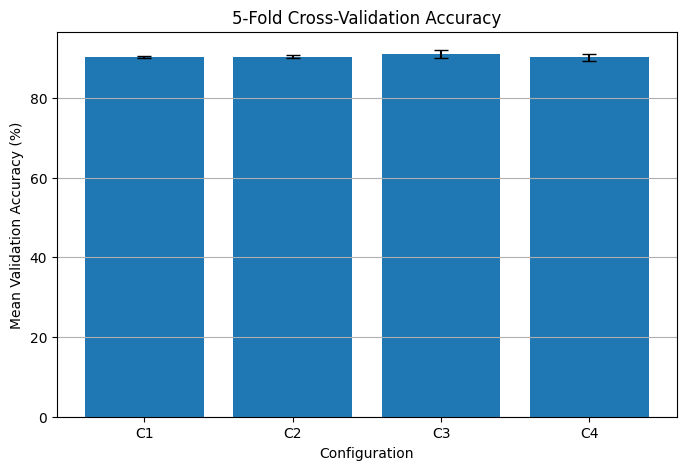

In [25]:
# ==========================================
# PLOT 13
# 5-FOLD CV ACCURACY
# ==========================================

plt.figure(figsize=(8, 5))

plt.bar(
    cv_results_df["Configuration"],
    cv_results_df["Mean Accuracy"] * 100,
    yerr=cv_results_df["SD"] * 100,
    capsize=5
)

plt.xlabel(
    "Configuration"
)

plt.ylabel(
    "Mean Validation Accuracy (%)"
)

plt.title(
    "5-Fold Cross-Validation Accuracy"
)

plt.grid(
    axis="y"
)

plt.show()

In [26]:
# ==========================================
# SELECT BEST CV CONFIGURATION
# ==========================================

best_idx = cv_results_df[
    "Mean Accuracy"
].idxmax()

best_config_name = cv_results_df.loc[
    best_idx,
    "Configuration"
]

best_mean_accuracy = cv_results_df.loc[
    best_idx,
    "Mean Accuracy"
]

best_sd = cv_results_df.loc[
    best_idx,
    "SD"
]

print(
    "Best CV Configuration:",
    best_config_name
)

print(
    f"Mean CV Accuracy: "
    f"{best_mean_accuracy * 100:.2f}%"
)

print(
    f"Standard Deviation: "
    f"{best_sd * 100:.2f}%"
)

print(
    "\nConfiguration details:"
)

print(
    cv_configurations[
        best_config_name
    ]
)

Best CV Configuration: C3
Mean CV Accuracy: 91.07%
Standard Deviation: 0.97%

Configuration details:
{'optimizer': 'Adam', 'learning_rate': 0.001, 'batch_size': 32, 'dropout': 0.5}


In [27]:
# ==========================================
# FINAL CONFIGURATION
# ==========================================

best_config = cv_configurations[
    best_config_name
]

print(
    "Final selected configuration:"
)

print(
    best_config
)

Final selected configuration:
{'optimizer': 'Adam', 'learning_rate': 0.001, 'batch_size': 32, 'dropout': 0.5}


In [28]:
# ==========================================
# BUILD FINAL MODEL
# ==========================================

final_model = build_cv_model(
    best_config["dropout"]
)

final_optimizer = keras.optimizers.Adam(
    learning_rate=best_config["learning_rate"]
)

final_model.compile(
    optimizer=final_optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [29]:
# ==========================================
# TRAIN FINAL MODEL
# ==========================================

FINAL_EPOCHS = 10

start_time = time.time()

final_history = final_model.fit(
    cv_images,
    cv_labels,
    batch_size=best_config["batch_size"],
    epochs=FINAL_EPOCHS,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

final_training_time = (
    time.time() - start_time
)

print(
    "Final training time:",
    final_training_time,
    "seconds"
)

Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 42s 409ms/step - accuracy: 0.5036 - loss: 1.8837 - val_accuracy: 0.8678 - val_loss: 0.5984
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8305 - loss: 0.5767 - val_accuracy: 0.8780 - val_loss: 0.3941
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8890 - loss: 0.3799 - val_accuracy: 0.8881 - val_loss: 0.3570
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9158 - loss: 0.2950 - val_accuracy: 0.8881 - val_loss: 0.3250
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9381 - loss: 0.2249 - val_accuracy: 0.8949 - val_loss: 0.3098
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9438 - loss: 0.1996 - val_accuracy: 0.9085 - val_loss: 0.2918
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9589 - loss: 0.1675 - val_accuracy: 0.9017 - val_loss: 0.2960
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9622 - loss: 0.1445 - val_accuracy: 0.9017 -

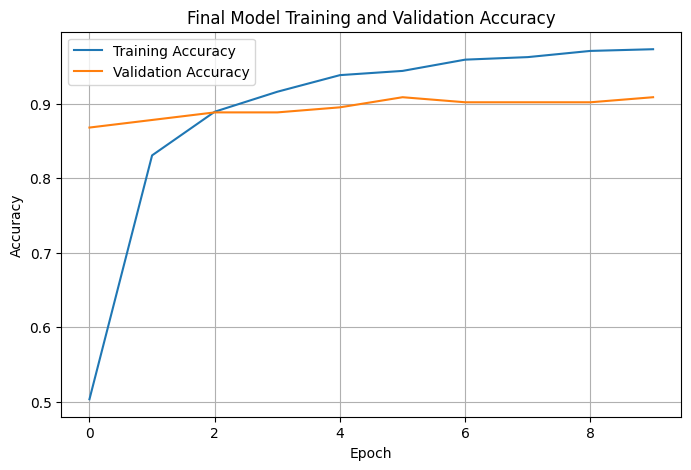

In [30]:
# ==========================================
# FINAL MODEL ACCURACY
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    final_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Final Model Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

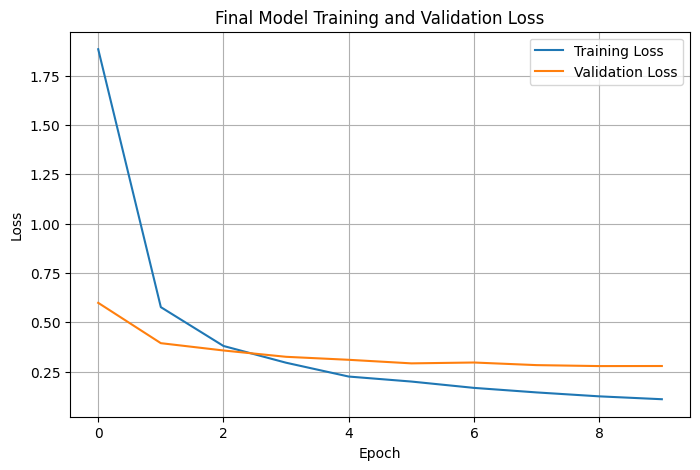

In [31]:
# ==========================================
# FINAL MODEL LOSS
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Final Model Training and Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

In [32]:
# ==========================================
# FINAL INDEPENDENT TEST EVALUATION
# ==========================================

test_loss, test_accuracy = final_model.evaluate(
    test_ds,
    verbose=1
)

print(
    f"Final Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Final Test Loss: "
    f"{test_loss:.4f}"
)

115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 193ms/step - accuracy: 0.9024 - loss: 0.3127
Final Test Accuracy: 90.24%
Final Test Loss: 0.3127


In [33]:
# ==========================================
# TEST PREDICTIONS
# ==========================================

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = final_model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_labels
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(
    "Number of test samples:",
    len(y_true)
)

# ==========================================
# CLASSIFICATION METRICS
# ==========================================

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print(
    f"Macro Precision: {precision:.4f}"
)

print(
    f"Macro Recall: {recall:.4f}"
)

print(
    f"Macro F1-score: {f1:.4f}"
)

Number of test samples: 3669
Macro Precision: 0.9035
Macro Recall: 0.9016
Macro F1-score: 0.9011


In [34]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

class_names = (
    ds_info
    .features["label"]
    .names
)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

                            precision    recall  f1-score   support

                Abyssinian       0.85      0.95      0.90        98
          american_bulldog       0.73      0.89      0.80       100
 american_pit_bull_terrier       0.72      0.68      0.70       100
              basset_hound       0.96      0.93      0.94       100
                    beagle       0.94      0.90      0.92       100
                    Bengal       0.84      0.80      0.82       100
                    Birman       0.76      0.84      0.80       100
                    Bombay       0.85      0.94      0.89        88
                     boxer       0.85      0.94      0.89        99
         British_Shorthair       0.84      0.80      0.82       100
                 chihuahua       0.89      0.89      0.89       100
              Egyptian_Mau       0.89      0.85      0.87        97
    english_cocker_spaniel       0.89      0.96      0.92       100
            english_setter       0.98      0.91

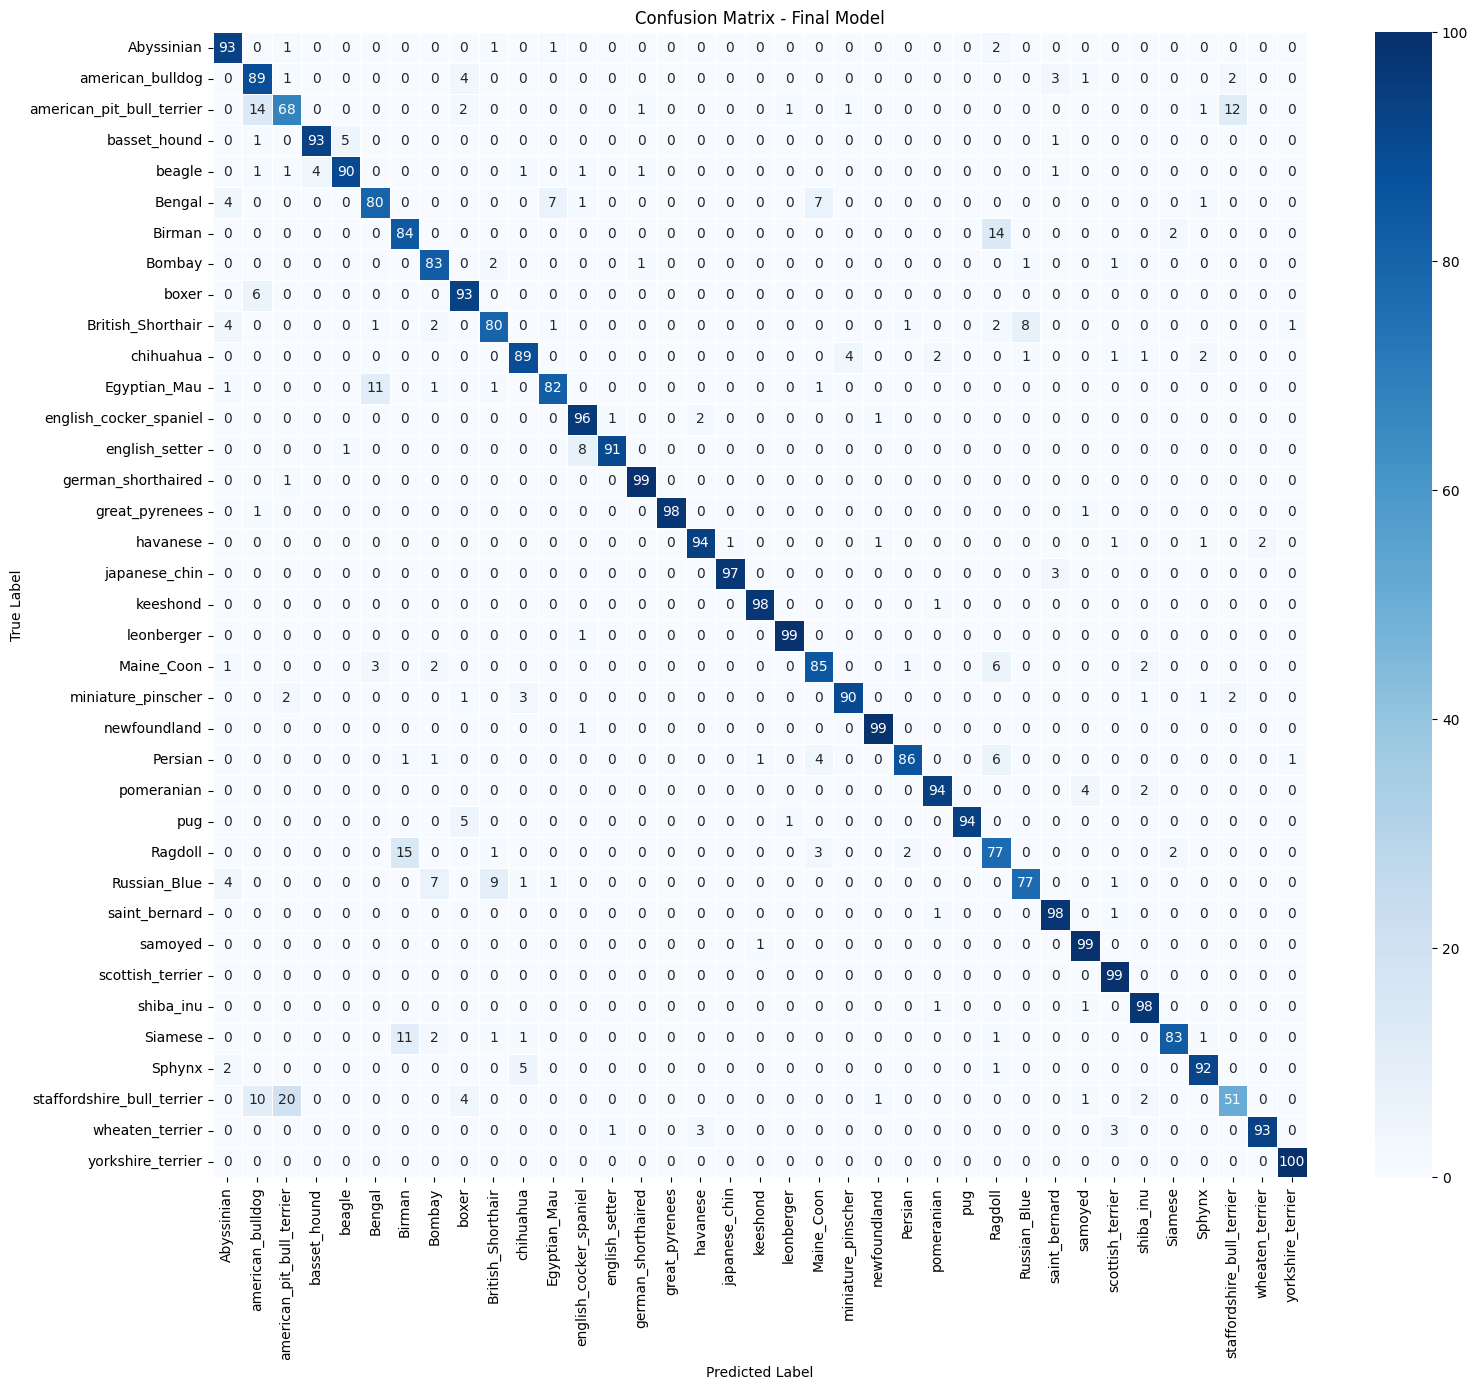

In [38]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Final Model")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

# Save as PNG and EPS
plt.savefig("confusion_matrix_final.png", dpi=300, bbox_inches="tight")
plt.savefig("confusion_matrix_final.eps", format="eps", bbox_inches="tight")

plt.show()

Total misclassified: 358


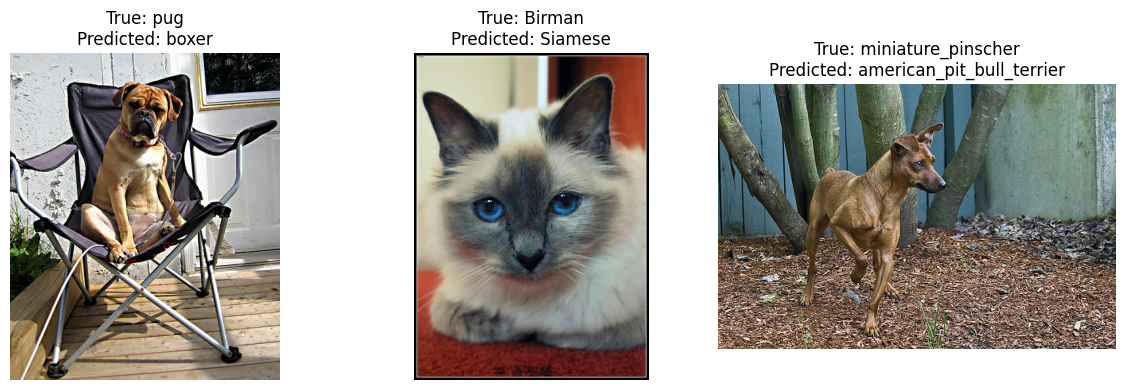

In [39]:
# ==========================================
# PLOT 15: MISCLASSIFIED IMAGES
# ==========================================

misclassified = np.where(y_true != y_pred)[0]

print("Total misclassified:", len(misclassified))

plt.figure(figsize=(12, 4))

for i, idx in enumerate(misclassified[:3]):
    image, true_label = list(ds_test.skip(int(idx)).take(1))[0]

    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.title(
        f"True: {class_names[y_true[idx]]}\n"
        f"Predicted: {class_names[y_pred[idx]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
# ==========================================
# FINAL EXPERIMENT SUMMARY
# ==========================================

final_summary = pd.DataFrame({
    "Metric": [
        "Best CV Configuration",
        "Mean CV Accuracy",
        "CV Standard Deviation",
        "Test Accuracy",
        "Test Loss",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Training Time (seconds)"
    ],

    "Value": [
        best_config_name,
        f"{best_mean_accuracy * 100:.2f}%",
        f"{best_sd * 100:.2f}%",
        f"{test_accuracy * 100:.2f}%",
        f"{test_loss:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        f"{final_training_time:.2f}"
    ]
})

final_summary

,Metric,Value
0,Best CV Configuration,C3
1,Mean CV Accuracy,91.07%
2,CV Standard Deviation,0.97%
3,Test Accuracy,90.24%
4,Test Loss,0.3127
5,Macro Precision,0.9035
6,Macro Recall,0.9016
7,Macro F1,0.9011
8,Training Time (seconds),74.56
